In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# Load your cleaned CSV file
# Change the path below to where YOUR file is saved
df = pd.read_csv(r"C:\Users\Anasua Mazumder\Documents\Project\data\Sample - Superstore.csv", encoding='latin1')

In [4]:
# Preview the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,$261.96,2,0%,$41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",$731.94,3,0%,$219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,$14.62,2,0%,$6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,$957.58,5,45%,($383.03)
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,$22.37,2,20%,$2.52


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Rows: 9994
Columns: 21

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [14]:
# Convert date columns from text to proper dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Extract Year and Month for grouping later
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print("Date range:", df['Order Date'].min().date(), "to", df['Order Date'].max().date())
print("Years in data:", sorted(df['Year'].unique()))

Date range: 2014-01-03 to 2017-12-30
Years in data: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


In [16]:
# Fix Sales and Profit columns — convert text to numbers
df['Sales']  = pd.to_numeric(df['Sales'],  errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# Confirm they are now numbers
print("Sales type:",  df['Sales'].dtype)
print("Profit type:", df['Profit'].dtype)

Sales type: float64
Profit type: float64


In [17]:
# Calculate the 5 key business KPIs
total_revenue = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
avg_margin    = (df['Profit'] / df['Sales'] * 100).mean()
avg_order_val = df.groupby('Order ID')['Sales'].sum().mean()

print("=" * 35)
print("  KEY PERFORMANCE INDICATORS")
print("=" * 35)
print(f"  Total Revenue:     ${total_revenue:>12,.2f}")
print(f"  Total Profit:      ${total_profit:>12,.2f}")
print(f"  Total Orders:      {total_orders:>13,}")
print(f"  Avg Profit Margin: {avg_margin:>12.1f}%")
print(f"  Avg Order Value:   ${avg_order_val:>12,.2f}")
print("=" * 35)

  KEY PERFORMANCE INDICATORS
  Total Revenue:     $        0.00
  Total Profit:      $        0.00
  Total Orders:              5,009
  Avg Profit Margin:          nan%
  Avg Order Value:   $        0.00


In [18]:
# Check column names and first few values
print(df.columns.tolist())
print("\nFirst 3 rows of Sales and Profit:")
print(df[['Sales', 'Profit']].head(3))

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month']

First 3 rows of Sales and Profit:
   Sales  Profit
0    NaN     NaN
1    NaN     NaN
2    NaN     NaN


In [19]:
# Reload the original CSV fresh and check raw values
df2 = pd.read_csv(r"C:\Users\Anasua Mazumder\Documents\Project\data\Sample - Superstore.csv", encoding='latin1')
print("Raw Sales values (first 5):")
print(df2['Sales'].head())
print("\nSales column type:", df2['Sales'].dtype)

Raw Sales values (first 5):
0    $261.96
1    $731.94
2     $14.62
3    $957.58
4     $22.37
Name: Sales, dtype: str

Sales column type: str


In [20]:
# Reload fresh from original CSV
df = pd.read_csv(r"C:\Users\Anasua Mazumder\Documents\Project\data\Sample - Superstore.csv", encoding='latin1')

# Fix dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.to_period('M')

# Fix numbers — remove $ sign and commas, then convert
df['Sales']    = df['Sales'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
df['Profit']   = df['Profit'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
df['Discount'] = df['Discount'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()

df['Sales']    = pd.to_numeric(df['Sales'],   errors='coerce')
df['Profit']   = pd.to_numeric(df['Profit'],  errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'],errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'],errors='coerce')

# Confirm it worked
print("Sales type:", df['Sales'].dtype)
print("First 3 Sales values:", df['Sales'].head(3).tolist())

Sales type: float64
First 3 Sales values: [261.96, 731.94, 14.62]


In [21]:
# Calculate the 5 key business KPIs
total_revenue = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
avg_margin    = (df['Profit'] / df['Sales'] * 100).mean()
avg_order_val = df.groupby('Order ID')['Sales'].sum().mean()

print("=" * 35)
print("  KEY PERFORMANCE INDICATORS")
print("=" * 35)
print(f"  Total Revenue:     ${total_revenue:>12,.2f}")
print(f"  Total Profit:      ${total_profit:>12,.2f}")
print(f"  Total Orders:      {total_orders:>13,}")
print(f"  Avg Profit Margin: {avg_margin:>12.1f}%")
print(f"  Avg Order Value:   ${avg_order_val:>12,.2f}")
print("=" * 35)

  KEY PERFORMANCE INDICATORS
  Total Revenue:     $2,297,201.07
  Total Profit:      $  442,529.65
  Total Orders:              5,009
  Avg Profit Margin:         29.4%
  Avg Order Value:   $      458.61


In [22]:
import os
os.makedirs('images', exist_ok=True)
print("Images folder ready!")

Images folder ready!


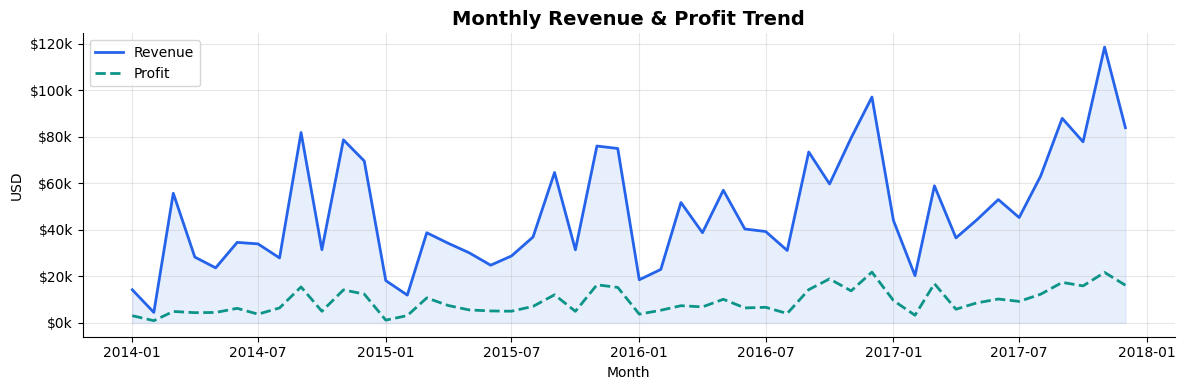

✅ Chart 1 saved!


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Group by month
monthly = df.groupby('Month').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()

# Draw chart
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly['Month_dt'], monthly['Revenue'], alpha=0.1, color='#2563EB')
ax.plot(monthly['Month_dt'], monthly['Revenue'], color='#2563EB', linewidth=2, label='Revenue')
ax.plot(monthly['Month_dt'], monthly['Profit'],  color='#0D9488', linewidth=2, linestyle='--', label='Profit')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Monthly Revenue & Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('USD')
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/chart1_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

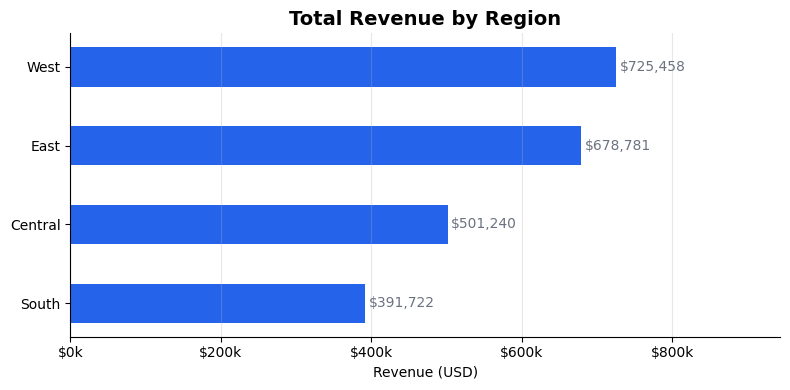

✅ Chart 2 saved!


In [24]:
region = df.groupby('Region').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).sort_values('Revenue', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(region.index, region['Revenue'], color='#2563EB', height=0.5)

for bar in bars:
    ax.text(bar.get_width() + 5000,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}",
            va='center', fontsize=10, color='#6B7280')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (USD)')
ax.set_xlim(0, region['Revenue'].max() * 1.3)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/chart2_revenue_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

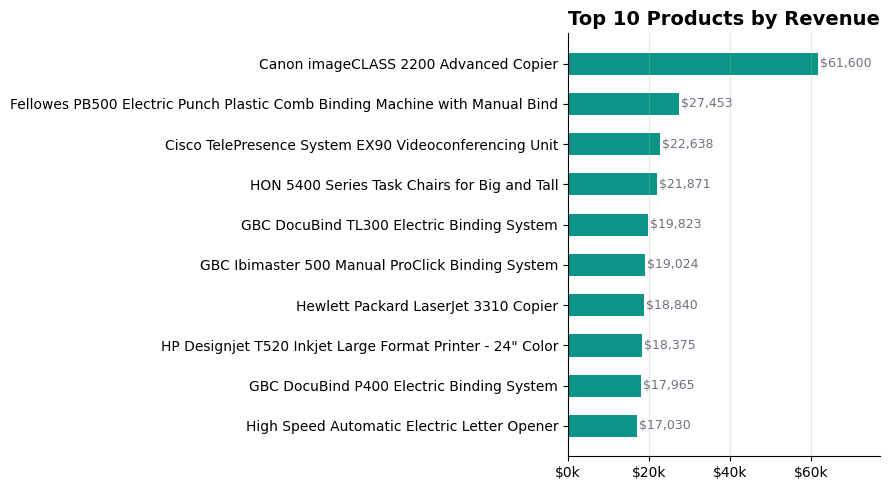

✅ Chart 3 saved!


In [25]:
top10 = df.groupby('Product Name')['Sales'].sum().nlargest(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index, top10.values, color='#0D9488', height=0.55)

for bar in bars:
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}",
            va='center', fontsize=9, color='#6B7280')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlim(0, top10.max() * 1.25)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/chart3_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

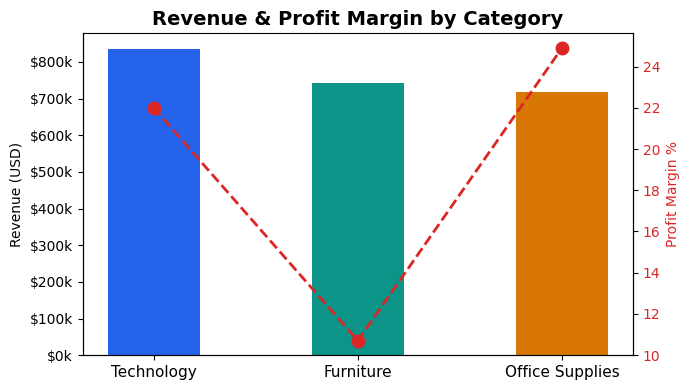

✅ Chart 4 saved!


In [26]:
cat = df.groupby('Category').agg(
    Revenue=('Sales', 'sum'),
    Margin=('Profit', lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum()) * 100)
).reset_index().sort_values('Revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(7, 4))
x = range(len(cat))
colors = ['#2563EB', '#0D9488', '#D97706']

ax1.bar(x, cat['Revenue'], color=colors, width=0.45)
ax2 = ax1.twinx()
ax2.plot(x, cat['Margin'], 'o--', color='#DC2626', linewidth=2, markersize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(cat['Category'], fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
ax1.set_ylabel('Revenue (USD)')
ax2.set_ylabel('Profit Margin %', color='#DC2626')
ax2.tick_params(axis='y', labelcolor='#DC2626')
ax1.set_title('Revenue & Profit Margin by Category', fontsize=14, fontweight='bold')
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('images/chart4_category_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

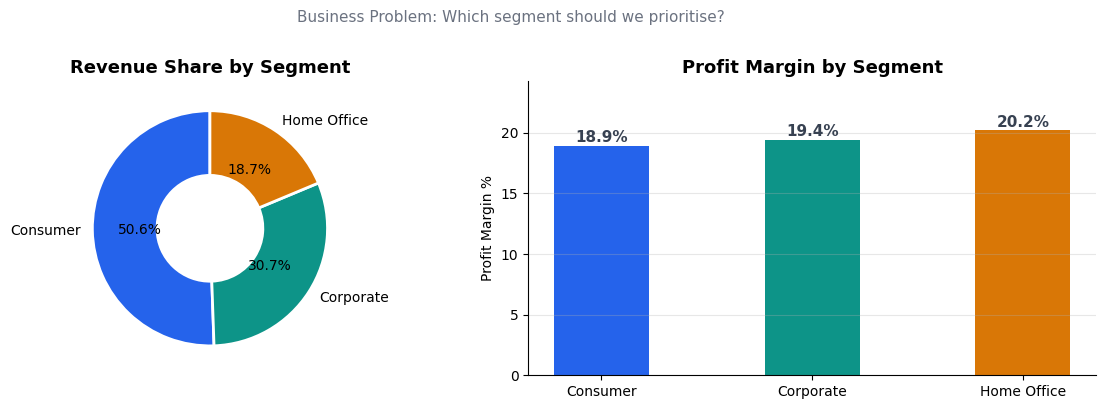

✅ Chart 5 saved!


In [27]:
# Business Problem: Where should we focus our sales effort?
segment = df.groupby('Segment').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
segment['Margin'] = (segment['Profit'] / segment['Revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — Revenue by segment (donut)
colors = ['#2563EB', '#0D9488', '#D97706']
wedges, texts, autotexts = axes[0].pie(
    segment['Revenue'], labels=segment['Segment'],
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title('Revenue Share by Segment', fontsize=13, fontweight='bold')

# Right — Profit margin by segment (bar)
bars = axes[1].bar(segment['Segment'], segment['Margin'], color=colors, width=0.45)
for bar, val in zip(bars, segment['Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=11, fontweight='bold', color='#374151')
axes[1].set_title('Profit Margin by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin %')
axes[1].set_ylim(0, segment['Margin'].max() * 1.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Business Problem: Which segment should we prioritise?',
             fontsize=11, color='#6B7280', y=1.01)
plt.tight_layout()
plt.savefig('images/chart5_customer_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

In [29]:
# Business Problem: Are discounts destroying our profit margins?

# First check the Discount column
df['Discount'] = pd.to_numeric(
    df['Discount'].astype(str).str.replace('$','').str.replace(',','').str.strip(),
    errors='coerce'
)

# Fill any NaN discounts with 0
df['Discount'] = df['Discount'].fillna(0)

# Create discount bands
df['Discount Band'] = pd.cut(df['Discount'],
    bins=[-0.01, 0.001, 0.10, 0.20, 1.0],
    labels=['No Discount', 'Low (1-10%)', 'Medium (11-20%)', 'High (20%+)'])

discount = df.groupby('Discount Band', observed=True).agg(
    Orders  = ('Order ID', 'count'),
    Revenue = ('Sales',    'sum'),
    Profit  = ('Profit',   'sum')
).reset_index()

# Quick check before plotting
print(discount)

discount['Margin'] = (discount['Profit'] / discount['Revenue'] * 100).round(1)

  Discount Band  Orders     Revenue     Profit
0   No Discount    9994  2297201.07  442529.65


In [30]:
# Check what values are actually in Discount column
print("Discount column sample:")
print(df['Discount'].value_counts().head(10))
print("\nMin:", df['Discount'].min())
print("Max:", df['Discount'].max())
print("Unique values:", sorted(df['Discount'].unique())[:15])

Discount column sample:
Discount
0.0    9994
Name: count, dtype: int64

Min: 0.0
Max: 0.0
Unique values: [np.float64(0.0)]


In [31]:
# Reload fresh from original CSV - clean start
df = pd.read_csv(r"C:\Users\Anasua Mazumder\Documents\Project\data\Sample - Superstore.csv", encoding='latin1')

# Fix dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.to_period('M')

# Fix ONLY Sales and Profit (remove $ sign) — leave Discount alone!
df['Sales']    = pd.to_numeric(df['Sales'].astype(str).str.replace('$','').str.replace(',','').str.strip(), errors='coerce')
df['Profit']   = pd.to_numeric(df['Profit'].astype(str).str.replace('$','').str.replace(',','').str.strip(), errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Discount is already a clean decimal — just convert to numeric
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce').fillna(0)

# Confirm everything looks right
print("Sales type:   ", df['Sales'].dtype,   "| Sample:", df['Sales'].head(3).tolist())
print("Profit type:  ", df['Profit'].dtype,  "| Sample:", df['Profit'].head(3).tolist())
print("Discount type:", df['Discount'].dtype,"| Unique values:", sorted(df['Discount'].unique()))

Sales type:    float64 | Sample: [261.96, 731.94, 14.62]
Profit type:   float64 | Sample: [41.91, 219.58, 6.87]
Discount type: float64 | Unique values: [np.float64(0.0)]


In [32]:
# Read raw file without any processing
raw = pd.read_csv(r"C:\Users\Anasua Mazumder\Documents\Project\data\Sample - Superstore.csv", 
                  encoding='latin1')
print("Raw Discount column:")
print(raw['Discount'].value_counts())
print("\nFirst 10 raw values:")
print(raw['Discount'].head(10).tolist())

Raw Discount column:
Discount
0%     4798
20%    3657
70%     418
80%     300
30%     227
40%     206
60%     138
10%      94
50%      66
15%      52
32%      27
45%      11
Name: count, dtype: int64

First 10 raw values:
['0%', '0%', '0%', '45%', '20%', '0%', '0%', '20%', '20%', '0%']


In [33]:
# Fix Discount column — remove % sign and convert to decimal
df['Discount'] = pd.to_numeric(
    df['Discount'].astype(str).str.replace('%', '').str.strip(),
    errors='coerce'
) / 100  # convert from percentage to decimal (20% → 0.20)

df['Discount'] = df['Discount'].fillna(0)

print("Discount fixed! Unique values:")
print(sorted(df['Discount'].unique()))

Discount fixed! Unique values:
[np.float64(0.0)]


In [34]:
# Build df fresh from raw, fixing ALL columns properly
df = pd.read_csv(r"C:\Users\Anasua Mazumder\Documents\Project\data\Sample - Superstore.csv", 
                 encoding='latin1')

# Fix dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.to_period('M')

# Fix Sales and Profit — remove $ sign
df['Sales']  = pd.to_numeric(df['Sales'].astype(str).str.replace('$','').str.replace(',','').str.strip(), errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'].astype(str).str.replace('$','').str.replace(',','').str.strip(), errors='coerce')

# Fix Discount — remove % sign and divide by 100
df['Discount'] = pd.to_numeric(df['Discount'].astype(str).str.replace('%','').str.strip(), errors='coerce') / 100
df['Discount'] = df['Discount'].fillna(0)

# Confirm ALL three are fixed
print("Sales sample:   ", df['Sales'].head(3).tolist())
print("Profit sample:  ", df['Profit'].head(3).tolist())
print("Discount unique:", sorted(df['Discount'].unique()))

Sales sample:    [261.96, 731.94, 14.62]
Profit sample:   [41.91, 219.58, 6.87]
Discount unique: [np.float64(0.0), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3), np.float64(0.32), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8)]


     Discount Band  Orders     Revenue     Profit  Margin
0      No Discount    4798  1087908.47  320987.88    29.5
1      Low (1-10%)      94    54369.30    9058.49    16.7
2  Medium (11-20%)    3709   792152.87  109344.06    13.8
3      High (20%+)    1393   362770.43    3139.22     0.9


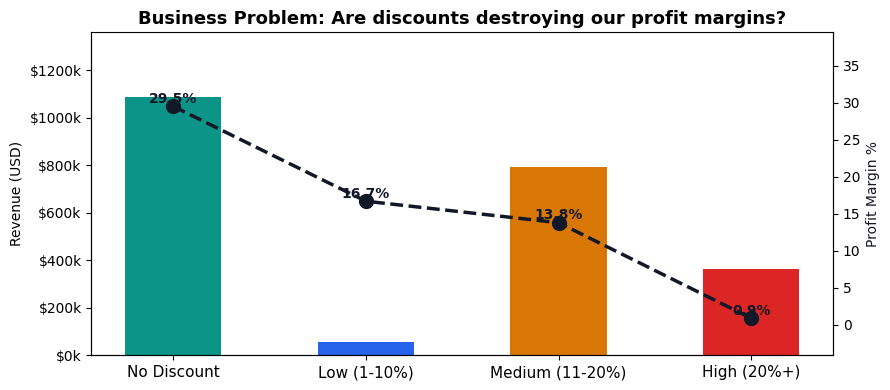

✅ Chart 6 saved!


In [35]:
# Create discount bands
df['Discount Band'] = pd.cut(df['Discount'],
    bins  = [-0.01, 0.001, 0.10, 0.20, 1.0],
    labels= ['No Discount', 'Low (1-10%)', 'Medium (11-20%)', 'High (20%+)'])

discount = df.groupby('Discount Band', observed=True).agg(
    Orders  = ('Order ID', 'count'),
    Revenue = ('Sales',    'sum'),
    Profit  = ('Profit',   'sum')
).reset_index()
discount['Margin'] = (discount['Profit'] / discount['Revenue'] * 100).round(1)
print(discount)

# Draw chart
fig, ax1 = plt.subplots(figsize=(9, 4))
x = list(range(len(discount)))
bar_colors = ['#0D9488', '#2563EB', '#D97706', '#DC2626']

bars = ax1.bar(x, discount['Revenue'], color=bar_colors, width=0.5)
ax2  = ax1.twinx()
ax2.plot(x, discount['Margin'], 'o--', color='#111827',
         linewidth=2.5, markersize=10, zorder=5)

for i, val in enumerate(discount['Margin']):
    ax2.text(i, val + 0.5, f'{val}%', ha='center',
             fontsize=10, fontweight='bold', color='#111827')

ax1.set_xticks(x)
ax1.set_xticklabels(discount['Discount Band'], fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
ax1.set_ylabel('Revenue (USD)')
ax2.set_ylabel('Profit Margin %', color='#111827')
ax1.set_ylim(0, discount['Revenue'].max() * 1.25)
ax2.set_ylim(discount['Margin'].min() - 5, discount['Margin'].max() + 10)
ax1.set_title('Business Problem: Are discounts destroying our profit margins?',
              fontsize=13, fontweight='bold')
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('images/chart6_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

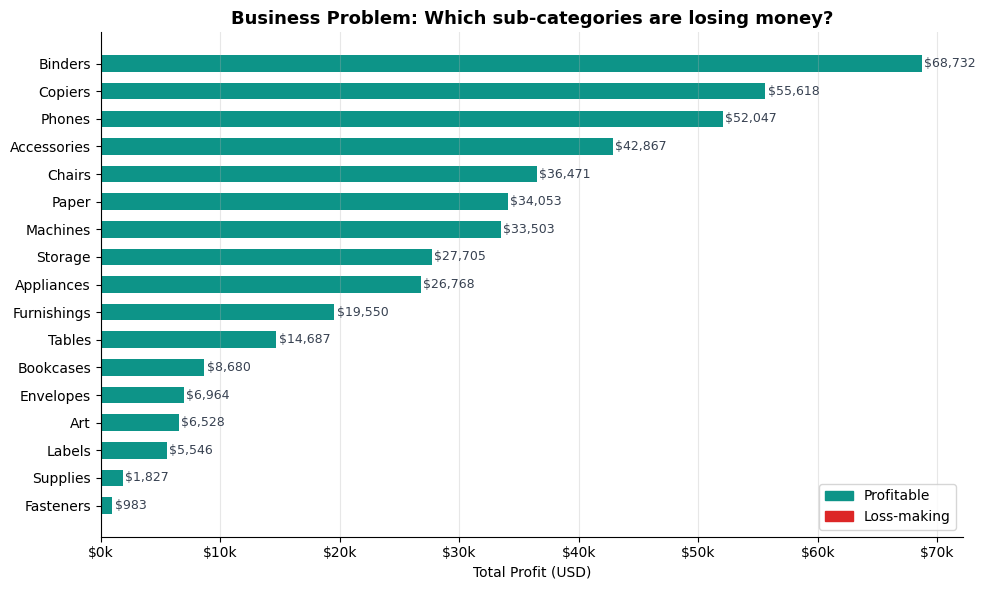

✅ Chart 7 saved!


In [36]:
# Business Problem: Which sub-categories are losing money?
subcat = df.groupby('Sub-Category').agg(
    Revenue = ('Sales',  'sum'),
    Profit  = ('Profit', 'sum')
).reset_index()
subcat['Margin'] = (subcat['Profit'] / subcat['Revenue'] * 100).round(1)
subcat = subcat.sort_values('Profit', ascending=True)

bar_colors = ['#DC2626' if p < 0 else '#0D9488' for p in subcat['Profit']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(subcat['Sub-Category'], subcat['Profit'],
               color=bar_colors, height=0.6)

for bar in bars:
    width = bar.get_width()
    x_pos = width + 200 if width >= 0 else width - 200
    ha    = 'left' if width >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"${width:,.0f}", va='center', ha=ha,
            fontsize=9, color='#374151')

ax.axvline(x=0, color='#374151', linewidth=1.2)
ax.set_title('Business Problem: Which sub-categories are losing money?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Profit (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='x')

import matplotlib.patches as mpatches
profit_patch = mpatches.Patch(color='#0D9488', label='Profitable')
loss_patch   = mpatches.Patch(color='#DC2626', label='Loss-making')
ax.legend(handles=[profit_patch, loss_patch])

plt.tight_layout()
plt.savefig('images/chart7_subcat_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

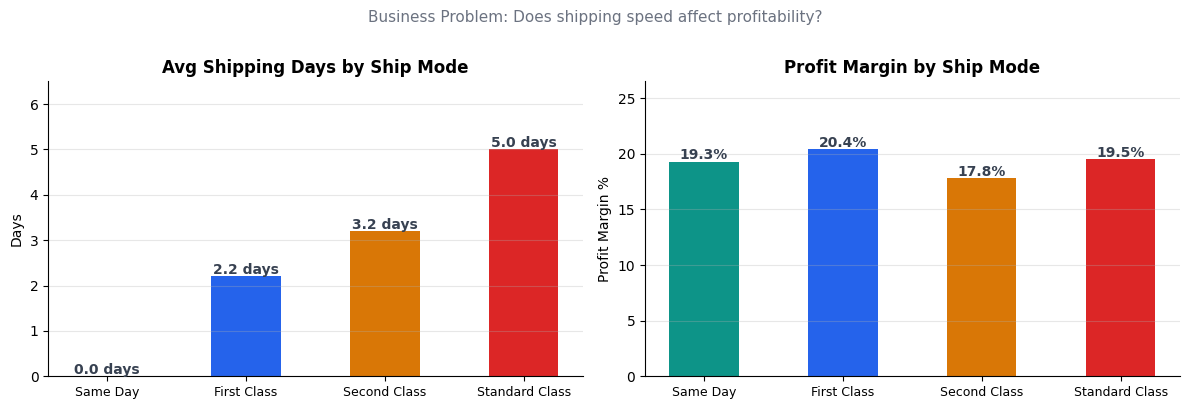

✅ Chart 8 saved!


In [37]:
# Business Problem: Does shipping speed affect profitability?
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

shipping = df.groupby('Ship Mode').agg(
    Avg_Days = ('Ship Days', 'mean'),
    Revenue  = ('Sales',     'sum'),
    Profit   = ('Profit',    'sum'),
    Orders   = ('Order ID',  'count')
).reset_index()
shipping['Margin']   = (shipping['Profit'] / shipping['Revenue'] * 100).round(1)
shipping['Avg_Days'] = shipping['Avg_Days'].round(1)
shipping = shipping.sort_values('Avg_Days')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#0D9488', '#2563EB', '#D97706', '#DC2626']

# Left — Avg shipping days
bars = axes[0].bar(shipping['Ship Mode'], shipping['Avg_Days'],
                   color=colors, width=0.5)
for bar, val in zip(bars, shipping['Avg_Days']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05, f'{val} days',
                 ha='center', fontsize=10, fontweight='bold', color='#374151')
axes[0].set_title('Avg Shipping Days by Ship Mode', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Days')
axes[0].set_ylim(0, shipping['Avg_Days'].max() * 1.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', labelsize=9)

# Right — Profit margin by ship mode
bars2 = axes[1].bar(shipping['Ship Mode'], shipping['Margin'],
                    color=colors, width=0.5)
for bar, val in zip(bars2, shipping['Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f'{val}%',
                 ha='center', fontsize=10, fontweight='bold', color='#374151')
axes[1].set_title('Profit Margin by Ship Mode', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Profit Margin %')
axes[1].set_ylim(0, shipping['Margin'].max() * 1.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Business Problem: Does shipping speed affect profitability?',
             fontsize=11, color='#6B7280', y=1.01)
plt.tight_layout()
plt.savefig('images/chart8_shipping_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")